# Question Clustering - Training Pipeline

Clusters questions using sentence embeddings and KMeans, determines optimal resolution per cluster, and outputs the trained model + resolution mapping.

In [1]:
# Setup: Determine project root
from pathlib import Path
import sys

# Find project root (contains pyproject.toml)
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "pyproject.toml").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError("Could not find project root (pyproject.toml)")
    PROJECT_ROOT = PROJECT_ROOT.parent

print(f"Project root: {PROJECT_ROOT}")
sys.path.insert(0, str(PROJECT_ROOT))

Project root: /mnt/c/All/GitHub/scale-wise-optimizer


In [2]:
import json
import re
import os
import pickle
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import friedmanchisquare
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from sentence_transformers import SentenceTransformer
import nltk
from nltk.corpus import stopwords

# Ensure NLTK data
for res in ['punkt', 'punkt_tab', 'averaged_perceptron_tagger', 'averaged_perceptron_tagger_eng', 'stopwords']:
    try: nltk.data.find(f'tokenizers/{res}' if 'punkt' in res else f'corpora/{res}' if res == 'stopwords' else f'taggers/{res}')
    except LookupError: nltk.download(res, quiet=True)

sns.set_style("whitegrid")
%matplotlib inline

/home/leomoura/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/leomoura/.local/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'Could not load this library: /home/leomoura/.local/lib/python3.10/site-packages/torchvision/image.so'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [3]:
# =============================================================================
# CONFIGURATION
# =============================================================================

# Dataset paths
DATA_PATH = str(PROJECT_ROOT/'benchmarks'/'seedbench'/'train.jsonl')
SCORES_SHEET = 'Consolidated_Scores'

# Clustering parameters
MIN_K = 5
MAX_K = 30
RANDOM_STATE = 42

# Resolutions to analyze
RESOLUTIONS = ['25000', '50000', '100000', '150000', '250000', '400000', '600000', '800000']

# Embedding model
EMBEDDING_MODEL = 'all-MiniLM-L6-v2'

# Output paths
MODEL_OUTPUT = str(PROJECT_ROOT / 'clustering/training/artifacts/clustering_model.pkl')
MAPPING_OUTPUT = str(PROJECT_ROOT / 'clustering/training/results/cluster_resolution_mapping.csv')

# Question type keywords
QUESTION_TYPES = {
    'counting': ['how many', 'count', 'number of', 'total'],
    'identification': ['which', 'what is', 'identify', 'name'],
    'comparison': ['compare', 'difference', 'larger', 'smaller', 'more', 'less', 'between'],
    'calculation': ['calculate', 'probability', 'percentage', 'ratio', 'fraction'],
    'location': ['where', 'located', 'position', 'region', 'area'],
    'temporal': ['when', 'year', 'date', 'time', 'deadline', 'schedule'],
    'relationship': ['relationship', 'connection', 'link', 'associated', 'related'],
    'visual_reference': ['diagram', 'chart', 'map', 'image', 'screenshot', 'graph', 'table', 'tree']
}

## 1. Data Loading & Preprocessing

In [4]:
import json
import numpy as np
import re   # ← faltava isso provavelmente

records = []

with open(DATA_PATH, "r", encoding="utf-8") as f:
    for line in f:
        obj = json.loads(line)

        row = {
            "doc_id": obj.get("doc_id"),
            "input":  obj.get("input", ""),
        }

        for res in RESOLUTIONS:
            row[res] = obj.get("scores", {}).get(res, np.nan)

        records.append(row)

df = pd.DataFrame(records)


# --- clean_input seguro ---
def clean_input(text):
    if not isinstance(text, str):
        return ""

    text = text.replace(
        "Answer with the option's letter from the given choices directly.",
        ""
    ).strip()

    match = re.search(r"\n[A-D]\.\s", text)
    return text[:match.start()].strip() if match else text


df["question_stem"] = df["input"].apply(clean_input)

print(f"Loaded {len(df)} questions")


Loaded 11386 questions


## 1.1. Features manuais extraídas

In [5]:
# Feature extraction
def extract_features(text):
    if not isinstance(text, str) or not text.strip():
        return {k: 0 for k in ['word_count', 'unique_word_ratio', 'noun_count', 'verb_count', 
                               'has_numbers', 'question_complexity'] + [f'is_{t}' for t in QUESTION_TYPES]}
    
    text_lower = text.lower()
    words = nltk.word_tokenize(text_lower)
    word_count = len(words)
    
    features = {
        'word_count': word_count,
        'char_count': len(text),
        'unique_word_ratio': len(set(words)) / max(word_count, 1),
        'has_numbers': 1 if re.search(r'\d', text) else 0,
        'number_count': len(re.findall(r'\d+\.?\d*', text)),
        'math_count': sum(text.count(s) for s in ['+', '-', '^', '=', '{', '}'])
    }
    
    # POS counts
    try:
        tagged = nltk.pos_tag(words)
        pos_counts = Counter(tag for _, tag in tagged)
        features['verb_count'] = sum(c for t, c in pos_counts.items() if t.startswith('VB'))
        features['noun_count'] = sum(c for t, c in pos_counts.items() if t.startswith('NN'))
        features['adj_count'] = sum(c for t, c in pos_counts.items() if t.startswith('JJ'))
    except:
        features['verb_count'] = features['noun_count'] = features['adj_count'] = 0
    
    # Question types
    for qtype, keywords in QUESTION_TYPES.items():
        features[f'is_{qtype}'] = 1 if any(kw in text_lower for kw in keywords) else 0
    
    features['question_complexity'] = word_count * 0.3 + len(set(words)) * 0.3 + features['math_count'] * 0.2
    return features

df_features = pd.DataFrame([extract_features(q) for q in df['question_stem']])
df = pd.concat([df, df_features], axis=1)
print(f"Extracted {len(df_features.columns)} features")

Extracted 18 features


## 2. Clustering

In [6]:
print("Loading sentence transformer model...")
model = SentenceTransformer('all-MiniLM-L6-v2')

print("Generating embeddings...")
embeddings = model.encode(df['question_stem'].tolist(), show_progress_bar=True)
print(f"Embeddings shape: {embeddings.shape}")

Loading sentence transformer model...
Generating embeddings...


Batches: 100%|██████████| 356/356 [00:26<00:00, 13.34it/s]

Embeddings shape: (11386, 384)


Finding optimal K...


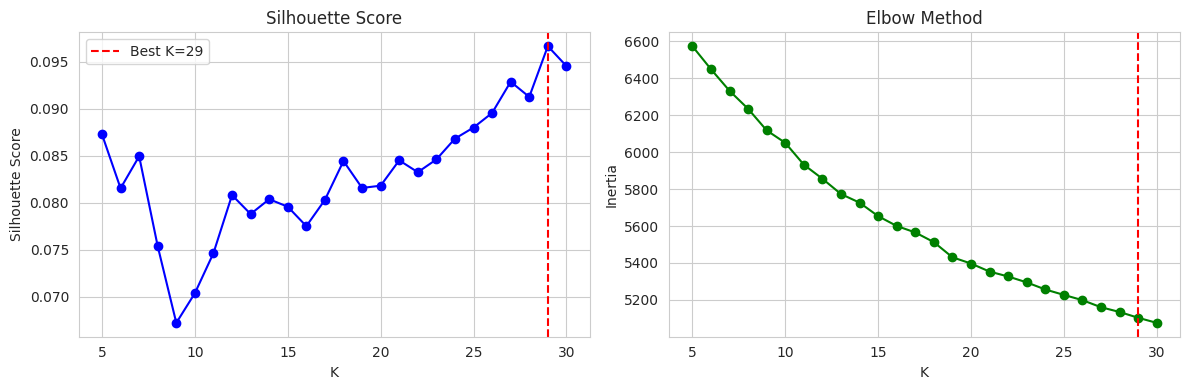


Optimal K: 29


In [7]:
# K Selection
k_range = range(MIN_K, MAX_K + 1)
silhouette_scores = []
inertias = []

print("Finding optimal K...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(embeddings)
    silhouette_scores.append(silhouette_score(embeddings, labels))
    inertias.append(kmeans.inertia_)

OPTIMAL_K = k_range[np.argmax(silhouette_scores)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(k_range, silhouette_scores, 'bo-')
ax1.axvline(OPTIMAL_K, color='red', linestyle='--', label=f'Best K={OPTIMAL_K}')
ax1.set_xlabel('K'); ax1.set_ylabel('Silhouette Score'); ax1.set_title('Silhouette Score'); ax1.legend()

ax2.plot(k_range, inertias, 'go-')
ax2.axvline(OPTIMAL_K, color='red', linestyle='--')
ax2.set_xlabel('K'); ax2.set_ylabel('Inertia'); ax2.set_title('Elbow Method')

plt.tight_layout()
plt.show()
print(f"\nOptimal K: {OPTIMAL_K}")

In [8]:
# Train final model and save
kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)
df['cluster'] = kmeans_final.fit_predict(embeddings)

# Save model
os.makedirs(os.path.dirname(MODEL_OUTPUT), exist_ok=True)
with open(MODEL_OUTPUT, 'wb') as f:
    pickle.dump({'kmeans': kmeans_final, 'embedding_model': EMBEDDING_MODEL, 'optimal_k': OPTIMAL_K}, f)

print(f"Model saved to {MODEL_OUTPUT}")
print(f"\nCluster distribution:")
print(df['cluster'].value_counts().sort_index())

Model saved to /mnt/c/All/GitHub/scale-wise-optimizer/clustering/training/artifacts/clustering_model.pkl

Cluster distribution:
cluster
0     223
1     546
2     256
3     642
4     680
5     528
6     712
7     248
8     435
9     224
10    169
11    387
12    401
13    350
14    590
15    224
16    279
17    365
18    313
19    146
20    420
21    277
22    268
23    212
24    618
25    256
26    799
27    683
28    135
Name: count, dtype: int64


Running t-SNE...


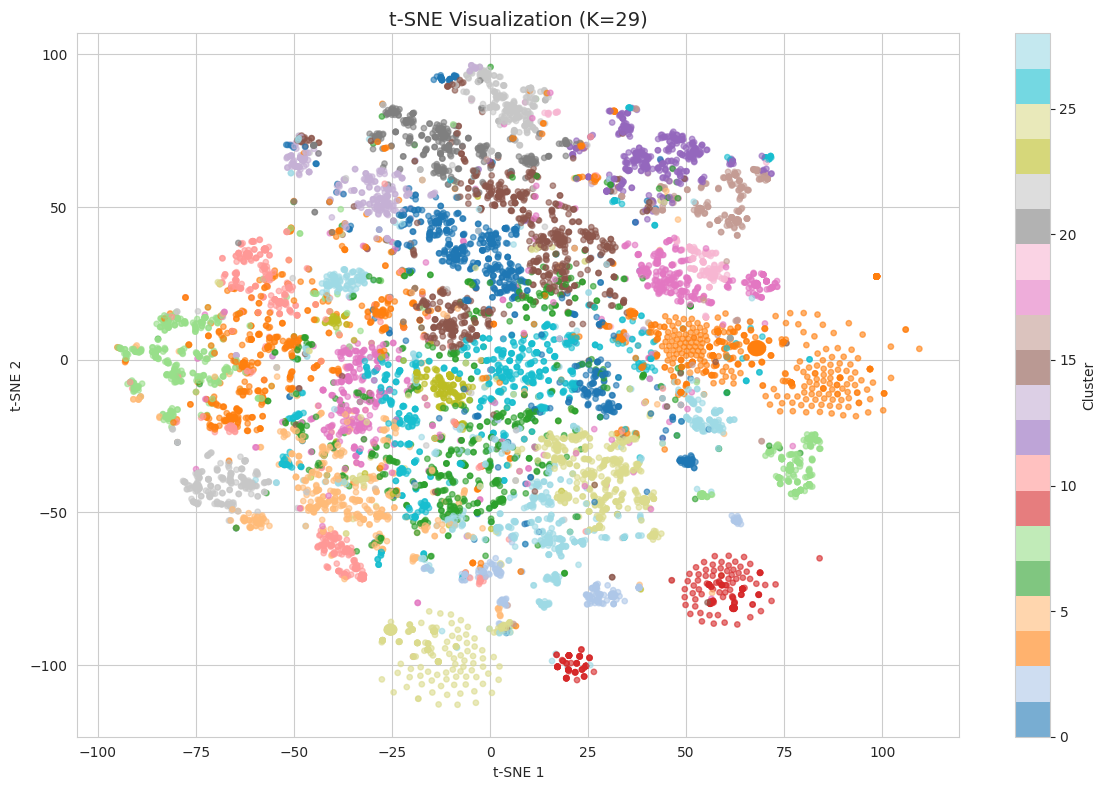

In [9]:
# t-SNE Visualization
print("Running t-SNE...")
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, init='pca', learning_rate='auto')
tsne_coords = tsne.fit_transform(embeddings)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(tsne_coords[:, 0], tsne_coords[:, 1], c=df['cluster'], cmap='tab20', alpha=0.6, s=15)
plt.colorbar(scatter, label='Cluster')
plt.title(f't-SNE Visualization (K={OPTIMAL_K})', fontsize=14)
plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2')
plt.tight_layout()
plt.show()

## 3. Resolution Analysis

In [10]:
# Compute accuracy per cluster per resolution
cluster_perf = []
for cluster_id in sorted(df['cluster'].unique()):
    subset = df[df['cluster'] == cluster_id]
    row = {'cluster': cluster_id, 'n_questions': len(subset)}
    for res in RESOLUTIONS:
        row[f'acc_{res}'] = subset[res].mean()
    cluster_perf.append(row)

df_cluster = pd.DataFrame(cluster_perf).set_index('cluster')

# Compute summary stats
acc_cols = [f'acc_{r}' for r in RESOLUTIONS]
df_cluster['mean_acc'] = df_cluster[acc_cols].mean(axis=1)
df_cluster['std_acc'] = df_cluster[acc_cols].std(axis=1)
df_cluster['min_acc'] = df_cluster[acc_cols].min(axis=1)
df_cluster['max_acc'] = df_cluster[acc_cols].max(axis=1)
df_cluster['range_acc'] = df_cluster['max_acc'] - df_cluster['min_acc']
df_cluster['best_resolution'] = df_cluster[acc_cols].idxmax(axis=1).str.replace('acc_', '')
df_cluster['worst_resolution'] = df_cluster[acc_cols].idxmin(axis=1).str.replace('acc_', '')

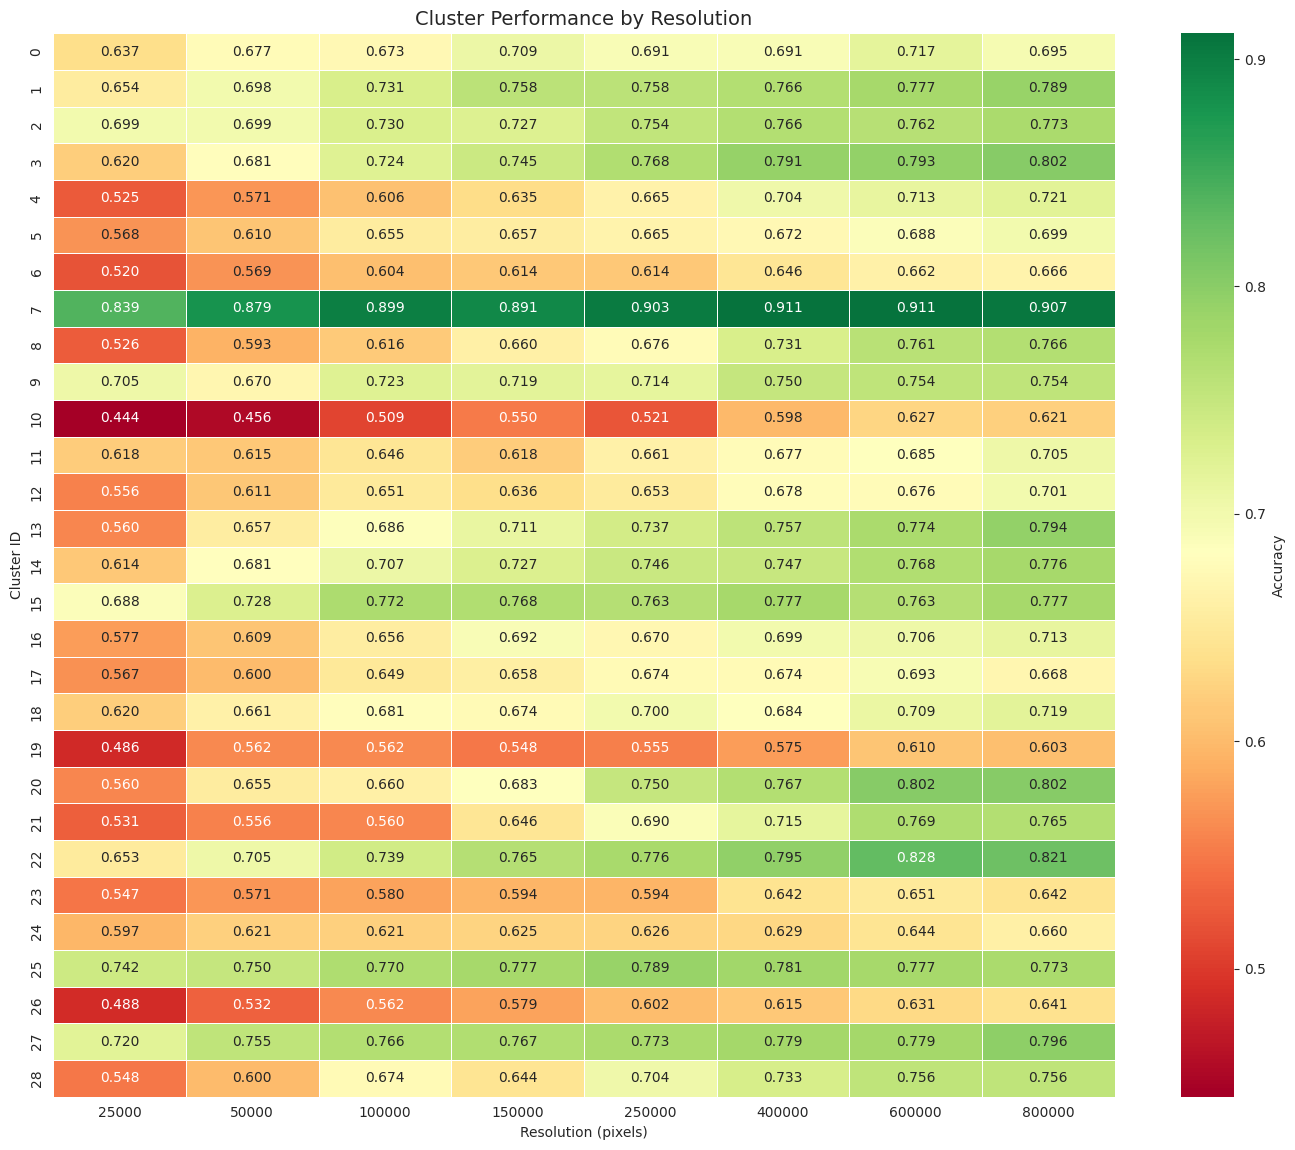

In [11]:
# Cluster Performance by Resolution - Heatmap
heatmap_data = df_cluster[acc_cols].copy()
heatmap_data.columns = RESOLUTIONS

plt.figure(figsize=(14, max(8, OPTIMAL_K * 0.4)))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn', 
            center=heatmap_data.values.mean(), linewidths=0.5, cbar_kws={'label': 'Accuracy'})
plt.title('Cluster Performance by Resolution', fontsize=14)
plt.xlabel('Resolution (pixels)'); plt.ylabel('Cluster ID')
plt.tight_layout()
plt.show()

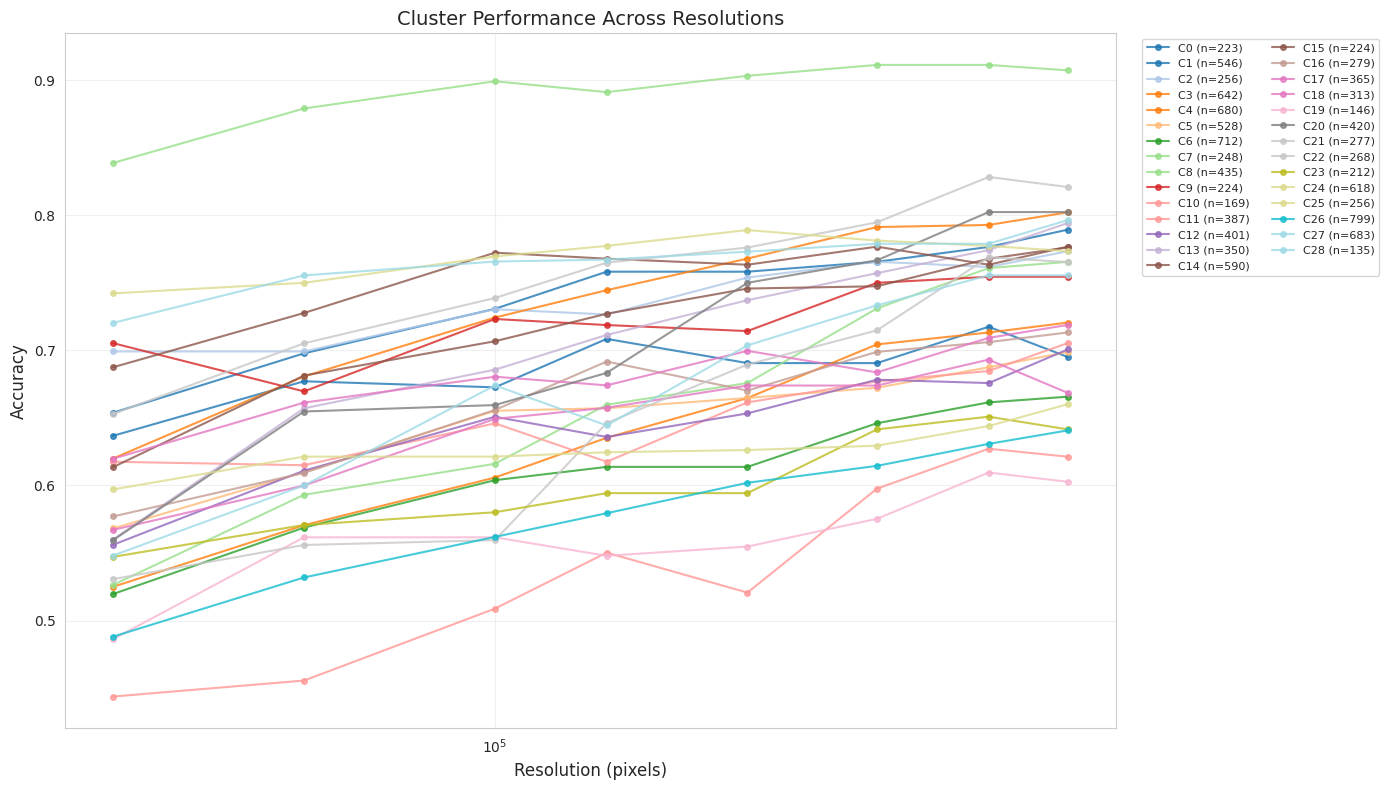

In [12]:
# Cluster Performance Across Resolutions - Line Plot
plt.figure(figsize=(14, 8))
resolutions_int = [int(r) for r in RESOLUTIONS]
colors = plt.cm.tab20(np.linspace(0, 1, OPTIMAL_K))

for cluster_id in sorted(df['cluster'].unique()):
    accuracies = [df_cluster.loc[cluster_id, f'acc_{r}'] for r in RESOLUTIONS]
    n = df_cluster.loc[cluster_id, 'n_questions']
    plt.plot(resolutions_int, accuracies, 'o-', color=colors[cluster_id], 
             label=f'C{cluster_id} (n={n})', linewidth=1.5, markersize=4, alpha=0.8)

plt.xlabel('Resolution (pixels)', fontsize=12); plt.ylabel('Accuracy', fontsize=12)
plt.title('Cluster Performance Across Resolutions', fontsize=14)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, ncol=2)
plt.xscale('log'); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# Cluster Resolution Sensitivity Analysis Table
sensitivity_table = df_cluster[['n_questions', 'mean_acc', 'std_acc', 'min_acc', 'max_acc', 
                                 'range_acc', 'best_resolution', 'worst_resolution']].copy()

print("=" * 100)
print("CLUSTER RESOLUTION SENSITIVITY ANALYSIS")
print("=" * 100)
display(sensitivity_table.round(4))

CLUSTER RESOLUTION SENSITIVITY ANALYSIS


,n_questions,mean_acc,std_acc,min_acc,max_acc,range_acc,best_resolution,worst_resolution
cluster,,,,,,,,
0,223,0.6861,0.0248,0.6368,0.7175,0.0807,600000,25000
1,546,0.7413,0.0453,0.6538,0.7894,0.1355,800000,25000
2,256,0.7388,0.0293,0.6992,0.7734,0.0742,800000,25000
3,642,0.7405,0.0635,0.6199,0.8022,0.1822,800000,25000
4,680,0.6425,0.0715,0.5250,0.7206,0.1956,800000,25000
5,528,0.6518,0.0429,0.5682,0.6989,0.1307,800000,25000
6,712,0.6117,0.0492,0.5197,0.6657,0.1461,800000,25000
7,248,0.8926,0.0244,0.8387,0.9113,0.0726,400000,25000
8,435,0.6661,0.0850,0.5264,0.7655,0.2391,800000,25000


## 4. Statistical Analysis

In [14]:
# Statistical Test Results by Cluster (Friedman Test)
stat_results = []
for cluster_id in sorted(df['cluster'].unique()):
    subset = df[df['cluster'] == cluster_id]
    scores = subset[RESOLUTIONS].values

    try:
        stat, p_val = friedmanchisquare(*[scores[:, i] for i in range(len(RESOLUTIONS))])
    except:
        stat, p_val = np.nan, np.nan

    stat_results.append({
        'cluster': cluster_id,
        'n_questions': len(subset),
        'friedman_stat': stat,
        'p_value': p_val,
        'significant (p<0.05)': p_val < 0.05 if not np.isnan(p_val) else False,
        'best_resolution': df_cluster.loc[cluster_id, 'best_resolution'],
        'best_accuracy': df_cluster.loc[cluster_id, 'max_acc'],
        'range_acc': df_cluster.loc[cluster_id, 'range_acc']
    })

df_friedman = pd.DataFrame(stat_results).sort_values('cluster').reset_index(drop=True)

sig_count = df_friedman['significant (p<0.05)'].sum()
print("=" * 100)
print("STATISTICAL TEST RESULTS BY CLUSTER (Friedman Test)")
print("=" * 100)
print(f"\nClusters where resolution significantly affects accuracy: {sig_count} / {OPTIMAL_K}")
print(f"Clusters where resolution does NOT significantly matter:  {OPTIMAL_K - sig_count} / {OPTIMAL_K}\n")
display(df_friedman.round(4))

STATISTICAL TEST RESULTS BY CLUSTER (Friedman Test)

Clusters where resolution significantly affects accuracy: 28 / 29
Clusters where resolution does NOT significantly matter:  1 / 29



,cluster,n_questions,friedman_stat,p_value,significant (p<0.05),best_resolution,best_accuracy,range_acc
0,0,223,18.7837,0.0089,True,600000,0.7175,0.0807
1,1,546,127.8657,0.0000,True,800000,0.7894,0.1355
2,2,256,25.8632,0.0005,True,800000,0.7734,0.0742
3,3,642,255.9408,0.0000,True,800000,0.8022,0.1822
4,4,680,237.2565,0.0000,True,800000,0.7206,0.1956
5,5,528,102.4870,0.0000,True,800000,0.6989,0.1307
6,6,712,168.5882,0.0000,True,800000,0.6657,0.1461
7,7,248,48.9044,0.0000,True,400000,0.9113,0.0726
8,8,435,203.1008,0.0000,True,800000,0.7655,0.2391
9,9,224,26.1925,0.0005,True,600000,0.7545,0.0848


## 5. Resolution Recommendations

In [15]:
# Resolution Recommendations: best, 95pct, 99pct + save CSV
os.makedirs(os.path.dirname(MAPPING_OUTPUT), exist_ok=True)

recommendations = []
for cluster_id in sorted(df['cluster'].unique()):
    row = df_cluster.loc[cluster_id]
    acc_at_res = {res: row[f'acc_{res}'] for res in RESOLUTIONS}

    best_res = max(acc_at_res, key=acc_at_res.get)
    best_acc = acc_at_res[best_res]

    # Efficient (95%)
    threshold_95 = best_acc * 0.95
    eff_95 = best_res
    for res in RESOLUTIONS:
        if acc_at_res[res] >= threshold_95:
            eff_95 = res
            break

    # Efficient (99%)
    threshold_99 = best_acc * 0.99
    eff_99 = best_res
    for res in RESOLUTIONS:
        if acc_at_res[res] >= threshold_99:
            eff_99 = res
            break

    recommendations.append({
        'cluster': cluster_id,
        'n_questions': row['n_questions'],
        'best_resolution': best_res,
        'best_accuracy': best_acc,
        'efficient_res_95pct': eff_95,
        'acc_at_95pct': acc_at_res[eff_95],
        'efficient_res_99pct': eff_99,
        'acc_at_99pct': acc_at_res[eff_99],
    })

df_rec = pd.DataFrame(recommendations).sort_values('cluster').reset_index(drop=True)
df_rec.to_csv(MAPPING_OUTPUT, index=False)

print(f"Resolution mapping saved to {MAPPING_OUTPUT}")
print("=" * 110)
print("RESOLUTION RECOMMENDATIONS BY CLUSTER")
print("=" * 110)
print("\n- best_resolution:      Resolution with highest accuracy")
print("- efficient_res_95pct:  Lowest resolution achieving >= 95% of best accuracy")
print("- efficient_res_99pct:  Lowest resolution achieving >= 99% of best accuracy\n")
display(df_rec.round(4))

Resolution mapping saved to /mnt/c/All/GitHub/scale-wise-optimizer/clustering/training/results/cluster_resolution_mapping.csv
RESOLUTION RECOMMENDATIONS BY CLUSTER

- best_resolution:      Resolution with highest accuracy
- efficient_res_95pct:  Lowest resolution achieving >= 95% of best accuracy
- efficient_res_99pct:  Lowest resolution achieving >= 99% of best accuracy



,cluster,n_questions,best_resolution,best_accuracy,efficient_res_95pct,acc_at_95pct,efficient_res_99pct,acc_at_99pct
0,0,223,600000,0.7175,150000,0.7085,600000,0.7175
1,1,546,800000,0.7894,150000,0.7582,800000,0.7894
2,2,256,800000,0.7734,250000,0.7539,800000,0.7734
3,3,642,800000,0.8022,250000,0.7679,800000,0.8022
4,4,680,800000,0.7206,400000,0.7044,800000,0.7206
5,5,528,800000,0.6989,250000,0.6648,800000,0.6989
6,6,712,800000,0.6657,400000,0.6461,600000,0.6615
7,7,248,400000,0.9113,50000,0.8790,250000,0.9032
8,8,435,800000,0.7655,400000,0.7310,600000,0.7609
9,9,224,600000,0.7545,100000,0.7232,400000,0.7500


In [16]:
# Summary Statistics
print("=" * 80)
print("SUMMARY")
print("=" * 80)
print(f"\nTotal questions: {len(df)}")
print(f"Number of clusters: {OPTIMAL_K}")
print(f"Cluster size range: {df_cluster['n_questions'].min()} - {df_cluster['n_questions'].max()}")
print(f"\nOverall accuracy at max resolution ({RESOLUTIONS[-1]}): {df[RESOLUTIONS[-1]].mean():.4f}")
print(f"Most resolution-sensitive cluster: {df_cluster['range_acc'].idxmax()} (range={df_cluster['range_acc'].max():.4f})")
print(f"Most resolution-stable cluster: {df_cluster['range_acc'].idxmin()} (range={df_cluster['range_acc'].min():.4f})")

# Resolution distribution
print(f"\nBest Resolution Distribution:")
for res in RESOLUTIONS:
    count = (df_rec['best_resolution'] == res).sum()
    if count > 0:
        questions = df_rec[df_rec['best_resolution'] == res]['n_questions'].sum()
        print(f"  {res}: {count} clusters ({questions} questions)")

SUMMARY

Total questions: 11386
Number of clusters: 29
Cluster size range: 135 - 799

Overall accuracy at max resolution (800000): 0.7336
Most resolution-sensitive cluster: 20 (range=0.2429)
Most resolution-stable cluster: 25 (range=0.0469)

Best Resolution Distribution:
  250000: 1 clusters (256 questions)
  400000: 2 clusters (472 questions)
  600000: 10 clusters (2439 questions)
  800000: 16 clusters (8219 questions)


## 6. Accuracy vs Computational Cost Trade-off

In [17]:
# Compute accuracy and cost for each strategy
RESOLUTION_VALUES = [int(r) for r in RESOLUTIONS]
MAX_RES = max(RESOLUTION_VALUES)
total_questions = df_rec['n_questions'].sum()

def compute_strategy(df_rec, df_cluster, res_col=None, fixed_res=None):
    """Compute weighted accuracy and relative cost for a strategy."""
    total_correct = 0
    total_cost = 0
    for _, row in df_rec.iterrows():
        cid = row['cluster']
        n = row['n_questions']
        res = fixed_res if fixed_res else str(int(row[res_col]))
        acc = df_cluster.loc[cid, f'acc_{res}']
        total_correct += acc * n
        total_cost += n * int(res)
    return total_correct / total_questions, total_cost / (total_questions * MAX_RES) * 100

# Fixed resolution strategies
fixed_results = []
for res in RESOLUTIONS:
    acc, cost = compute_strategy(df_rec, df_cluster, fixed_res=res)
    fixed_results.append({'strategy': f'All at {res}', 'accuracy': acc, 'cost_pct': cost})

# Cluster-based strategies
cluster_strategies = [
    ('Best per Cluster', 'best_resolution'),
    ('Efficient (95%)', 'efficient_res_95pct'),
    ('Efficient (99%)', 'efficient_res_99pct'),
]
cluster_results = []
for name, col in cluster_strategies:
    acc, cost = compute_strategy(df_rec, df_cluster, res_col=col)
    cluster_results.append({'strategy': name, 'accuracy': acc, 'cost_pct': cost})

df_fixed = pd.DataFrame(fixed_results)
df_cluster_strat = pd.DataFrame(cluster_results)
df_all_strat = pd.concat([df_fixed, df_cluster_strat], ignore_index=True)

print("STRATEGY COMPARISON")
print("=" * 60)
display(df_all_strat.round(4))

STRATEGY COMPARISON


,strategy,accuracy,cost_pct
0,All at 25000,0.5944,3.1250
1,All at 50000,0.6375,6.2500
2,All at 100000,0.6658,12.5000
3,All at 150000,0.6796,18.7500
4,All at 250000,0.6950,31.2500
5,All at 400000,0.7128,50.0000
6,All at 600000,0.7269,75.0000
7,All at 800000,0.7336,100.0000
8,Best per Cluster,0.7359,91.0263
9,Efficient (95%),0.7100,37.9545


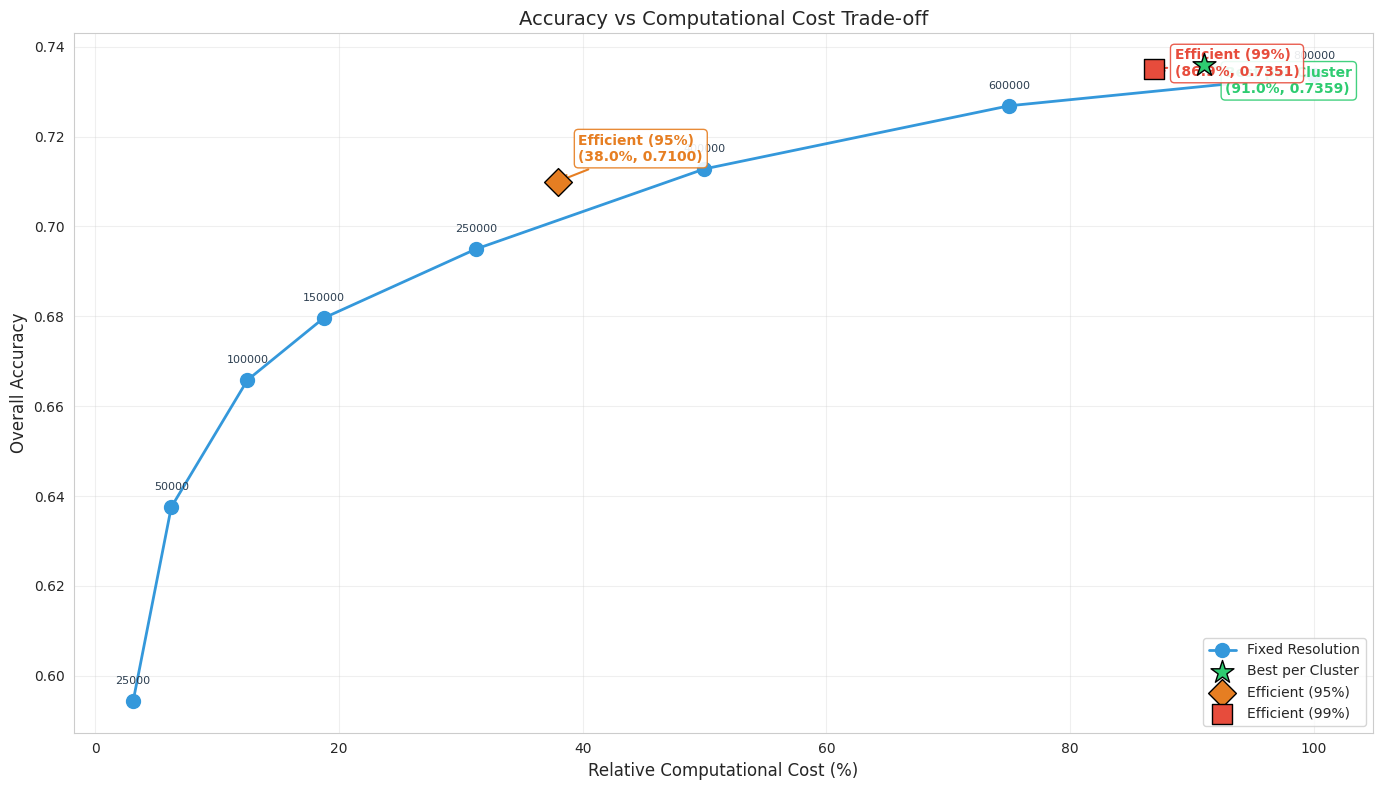

In [18]:
# Accuracy vs Computational Cost Trade-off
fig, ax = plt.subplots(figsize=(14, 8))

# Fixed resolution curve
ax.plot(df_fixed['cost_pct'], df_fixed['accuracy'], 'o-', color='#3498db',
        markersize=10, linewidth=2, label='Fixed Resolution', zorder=3)

for _, r in df_fixed.iterrows():
    ax.annotate(r['strategy'].replace('All at ', ''),
                (r['cost_pct'], r['accuracy']),
                textcoords='offset points', xytext=(0, 12), ha='center', fontsize=8, color='#2c3e50')

# Cluster-based strategies with prominent annotations
markers = {'Best per Cluster': ('*', '#2ecc71', 300), 
           'Efficient (95%)': ('D', '#e67e22', 200), 
           'Efficient (99%)': ('s', '#e74c3c', 200)}

for _, r in df_cluster_strat.iterrows():
    marker, color, size = markers[r['strategy']]
    ax.scatter(r['cost_pct'], r['accuracy'], marker=marker, c=color,
               s=size, zorder=5, edgecolors='black', linewidth=1, label=r['strategy'])

    # Annotate with visible (x, y) values
    ax.annotate(
        f"{r['strategy']}\n({r['cost_pct']:.1f}%, {r['accuracy']:.4f})",
        (r['cost_pct'], r['accuracy']),
        textcoords='offset points',
        xytext=(15, -20) if 'Best' in r['strategy'] else (15, 15) if '95' in r['strategy'] else (15, -5),
        fontsize=10, fontweight='bold', color=color,
        arrowprops=dict(arrowstyle='->', color=color, lw=1.5),
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=color, alpha=0.9)
    )

ax.set_xlabel('Relative Computational Cost (%)', fontsize=12)
ax.set_ylabel('Overall Accuracy', fontsize=12)
ax.set_title('Accuracy vs Computational Cost Trade-off', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()